In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from statsmodels.tsa.stattools import adfuller
from Src.Data_utils import differencing
from Src.Data_utils import cointegration
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from statsmodels.tsa.vector_ar.vecm import select_coint_rank,select_order


load_dotenv()

##Connect to sql database
engine = create_engine(
    f"mysql+pymysql://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@"
    f"{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DB')}"
)

##Load the data from SQL

data = pd.read_sql("SELECT * FROM GDP_inference_clean", engine)

data.columns = ["date", "Labor Productivity", "Unemployment Rate", "Federal Funds Rate", "Inflation", "GDP", "Population","Investment","Government Spending"]

data["GDP_per_capita"] = data["GDP"] / data["Population"]
print(data)

          date  Labor Productivity  Unemployment Rate  Federal Funds Rate  \
0   1999-01-01                 4.1                4.3                4.07   
1   1999-04-01                 3.9                4.3                5.41   
2   1999-07-01                 3.5                4.3                5.76   
3   1999-10-01                 4.2                4.1                5.26   
4   2000-01-01                 2.4                4.0                3.99   
..         ...                 ...                ...                 ...   
102 2024-07-01                 2.6                4.2                5.33   
103 2024-10-01                 1.9                4.1                4.83   
104 2025-01-01                 1.2                4.0                4.33   
105 2025-04-01                 1.5                4.2                4.33   
106 2025-07-01                 1.9                4.3                4.33   

     Inflation        GDP  Population  Investment  Government Spending  \
0

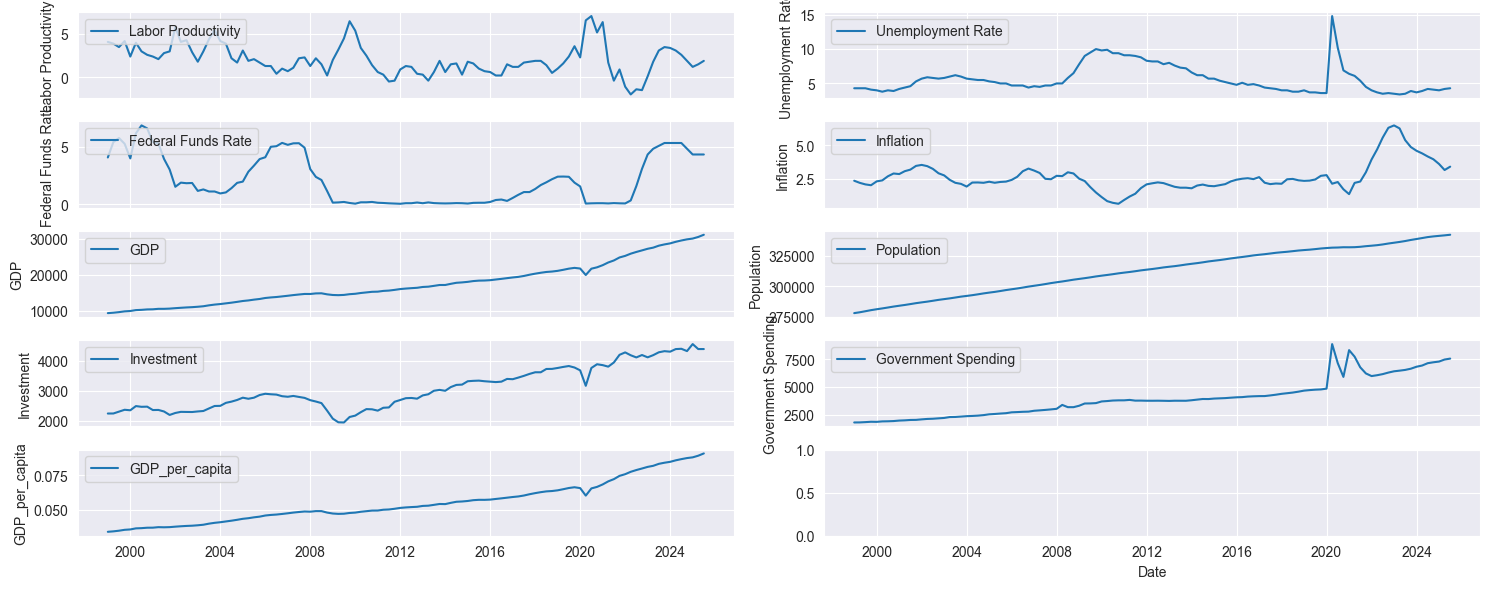

In [2]:
fig, axes = plt.subplots(5, 2, figsize=(15, 6), sharex=True)
axes = axes.flatten()
for i, column in enumerate(data.columns[1:]):
    axes[i].plot(data["date"], data[column], label=column, color='tab:blue')
    axes[i].set_ylabel(column)
    axes[i].legend(loc='upper left')

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [3]:
##Calculates unit roots to formally test stationarity
def dickey_fuller_test(data_test,regression):
    if "date" in data_test.columns:
        data_test = data_test.drop(["date"], axis=1)
    for i in data_test.columns:
        adf_result = adfuller(data_test[i], regression=regression)
        print(f"{i}, ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}")

dickey_fuller_test(data[["GDP_per_capita","GDP","Investment","Government Spending","Population"]],"ct")
dickey_fuller_test(data[["Labor Productivity","Unemployment Rate","Federal Funds Rate","Inflation"]],"c")

GDP_per_capita, ADF Statistic: 0.5400818770449792, p-value: 0.9969174794279753
GDP, ADF Statistic: 0.8460930490056591, p-value: 1.0
Investment, ADF Statistic: -1.9287545737998988, p-value: 0.6396414384434813
Government Spending, ADF Statistic: -3.021936405857581, p-value: 0.1260509850070196
Population, ADF Statistic: -0.07041065283265054, p-value: 0.9934461257884178
Labor Productivity, ADF Statistic: -2.647342199091129, p-value: 0.0836019251661389
Unemployment Rate, ADF Statistic: -3.356036559929701, p-value: 0.012552057067490954
Federal Funds Rate, ADF Statistic: -3.3517440496920505, p-value: 0.0127181187577239
Inflation, ADF Statistic: -0.6413610855359999, p-value: 0.8613596110590196


In [4]:
data[["GDP_per_capita","GDP","Investment","Government Spending","Population"]]

,GDP_per_capita,GDP,Investment,Government Spending,Population
0,0.033868,9411.682,2243.548,1811.988,277891.0
1,0.034195,9526.210,2244.682,1816.961,278584.0
2,0.034663,9686.626,2306.470,1843.205,279448.0
3,0.035315,9900.169,2367.988,1875.154,280337.0
4,0.035584,10002.179,2351.223,1866.308,281083.0
...,...,...,...,...,...
102,0.086685,29511.664,4392.176,7165.663,340448.0
103,0.087463,29825.182,4315.564,7247.662,341002.0
104,0.087983,30042.113,4547.947,7313.597,341454.0
105,0.089172,30485.729,4382.819,7496.339,341874.0


In [5]:
##Differencing the data and calculating Dickey Fuller on the new data
exclude = ["Unemployment Rate", "Federal Funds Rate","GDP","Population"]
data_i1 = data.loc[:, ~data.columns.isin(exclude)]
Differenced_data = differencing(data_i1)
dickey_fuller_test(Differenced_data,"c")

diffed_Labor Productivity, ADF Statistic: -4.755670461545205, p-value: 6.606206511494831e-05
diffed_Inflation, ADF Statistic: -3.0528823587255376, p-value: 0.030242363701342593
diffed_Investment, ADF Statistic: -10.419415422494307, p-value: 1.7201924231063009e-18
diffed_Government Spending, ADF Statistic: -5.296355299977705, p-value: 5.571647371508653e-06
diffed_GDP_per_capita, ADF Statistic: -10.164449770907831, p-value: 7.361572200755743e-18


In [6]:
Differenced_data=pd.concat([Differenced_data,data[["Unemployment Rate", "Federal Funds Rate"]]],axis=1)
Differenced_data.head()


,diffed_Labor Productivity,diffed_Inflation,diffed_Investment,diffed_Government Spending,diffed_GDP_per_capita,Unemployment Rate,Federal Funds Rate
1,-0.2,-0.156524,1.134,4.973,0.000327,4.3,5.41
2,-0.4,-0.115448,61.788,26.244,0.000468,4.3,5.76
3,0.7,-0.061524,61.518,31.949,0.000652,4.1,5.26
4,-1.8,0.285899,-16.765,-8.846,0.000269,4.0,3.99
5,1.6,0.073720,139.278,42.337,0.000786,3.8,6.17


In [7]:
##This function tests cointgeration between every time series combination and returns the p-values and significant combinations
cointegration(data_i1)
print(data_i1)

          date  Labor Productivity  Inflation  Investment  \
0   1999-01-01                 4.1   2.383116    2243.548   
1   1999-04-01                 3.9   2.226592    2244.682   
2   1999-07-01                 3.5   2.111144    2306.470   
3   1999-10-01                 4.2   2.049620    2367.988   
4   2000-01-01                 2.4   2.335519    2351.223   
..         ...                 ...        ...         ...   
102 2024-07-01                 2.6   4.182299    4392.176   
103 2024-10-01                 1.9   3.975247    4315.564   
104 2025-01-01                 1.2   3.624696    4547.947   
105 2025-04-01                 1.5   3.178169    4382.819   
106 2025-07-01                 1.9   3.427070    4383.186   

     Government Spending  GDP_per_capita  
0               1811.988        0.033868  
1               1816.961        0.034195  
2               1843.205        0.034663  
3               1875.154        0.035315  
4               1866.308        0.035584  
..       

In [8]:
lag_order = select_order(data_i1.iloc[:,1:], maxlags=10)
print(lag_order.summary())

##Johansen cointegration test using r metric
rank_test = select_coint_rank(data_i1.iloc[:,1:],
                              det_order=1,
                              k_ar_diff=2)
print(rank_test.summary())
## There exists 2 cointegration relations that we need to adjust for

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        3.396       4.197       29.87       3.720
1        2.785       4.254       16.28       3.379
2        1.862      3.999*       6.541       2.726
3        1.646       4.451       5.378       2.780
4        1.392       4.865       4.312       2.796
5        1.362       5.503       4.403       3.036
6        1.241       6.049       4.191       3.184
7       0.6732       6.149       2.626       2.887
8       0.1732       6.317       1.823       2.657
9      -0.2723       6.539      1.397*      2.481*
10    -0.2741*       7.205       1.764       2.749
--------------------------------------------------
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   5          115.2          79.34
  1   5          69.18          55.25
 

In [9]:
##Calculate descriptive statistics on stationary time series
Differenced_data.describe()

,diffed_Labor Productivity,diffed_Inflation,diffed_Investment,diffed_Government Spending,diffed_GDP_per_capita,Unemployment Rate,Federal Funds Rate
count,106.000000,106.000000,106.000000,106.000000,106.000000,107.000000,107.000000
mean,-0.020755,0.009849,20.185264,54.417368,0.000537,5.635514,2.097103
std,1.184963,0.306447,111.845478,520.546708,0.000902,2.024578,2.092250
min,-4.700000,-0.870839,-512.766000,-1717.262000,-0.005465,3.400000,0.040000
25%,-0.775000,-0.158407,-22.561750,14.846000,0.000271,4.200000,0.130000
50%,-0.100000,-0.009177,13.600000,36.063000,0.000492,5.000000,1.400000
75%,0.700000,0.192061,72.115250,66.282250,0.000778,6.200000,4.080000
max,4.300000,0.945895,592.018000,4024.750000,0.005242,14.800000,6.860000


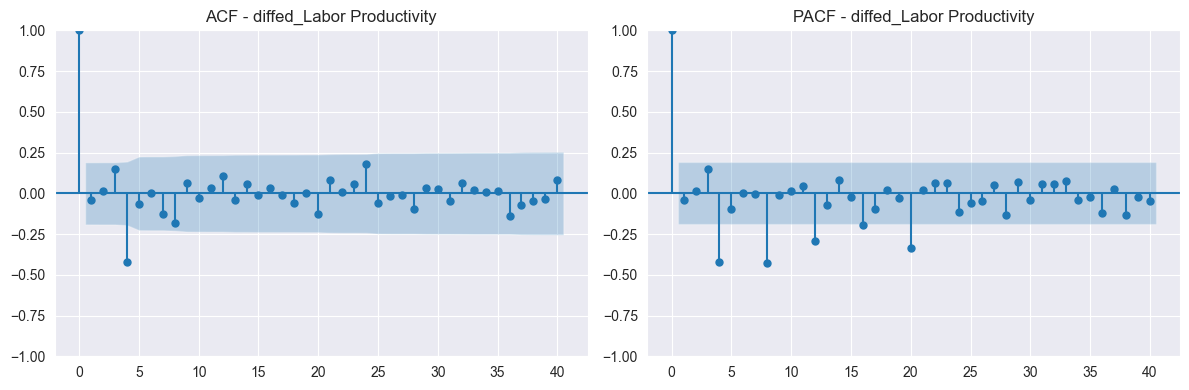

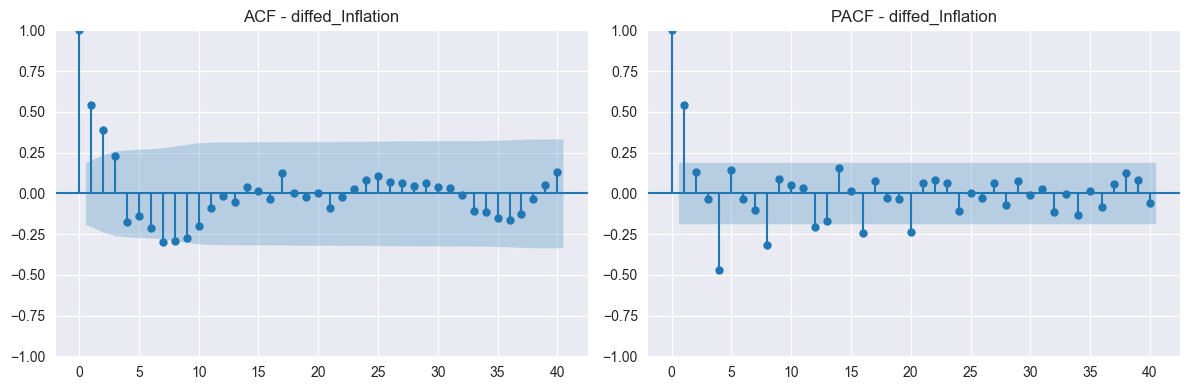

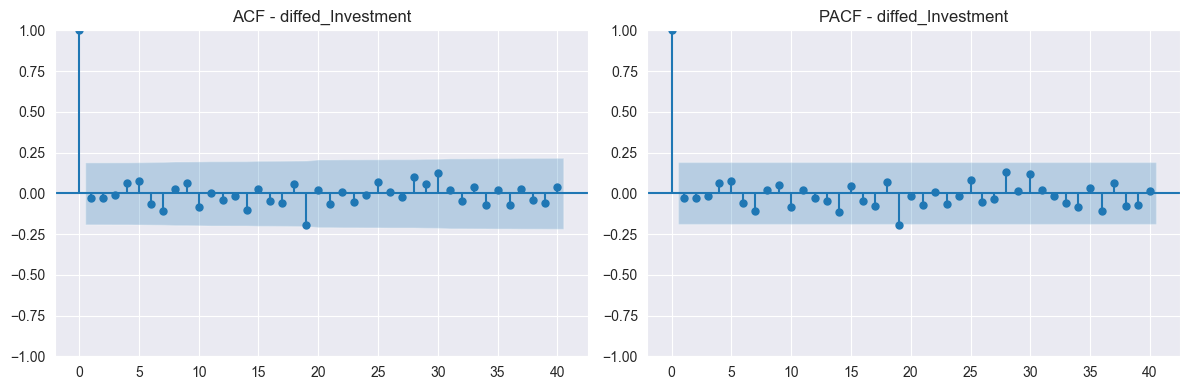

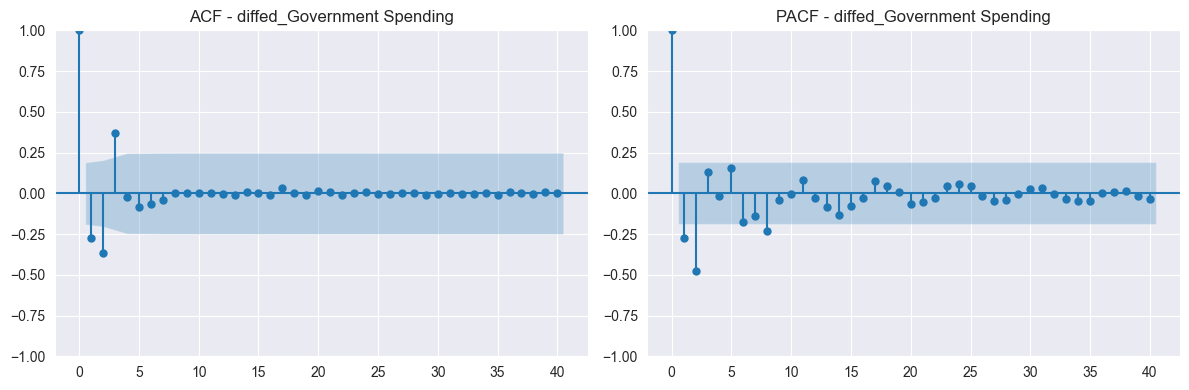

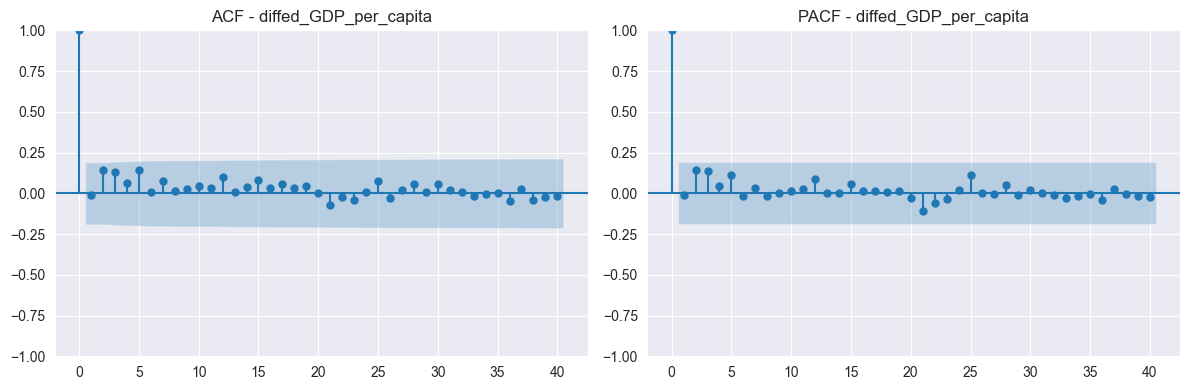

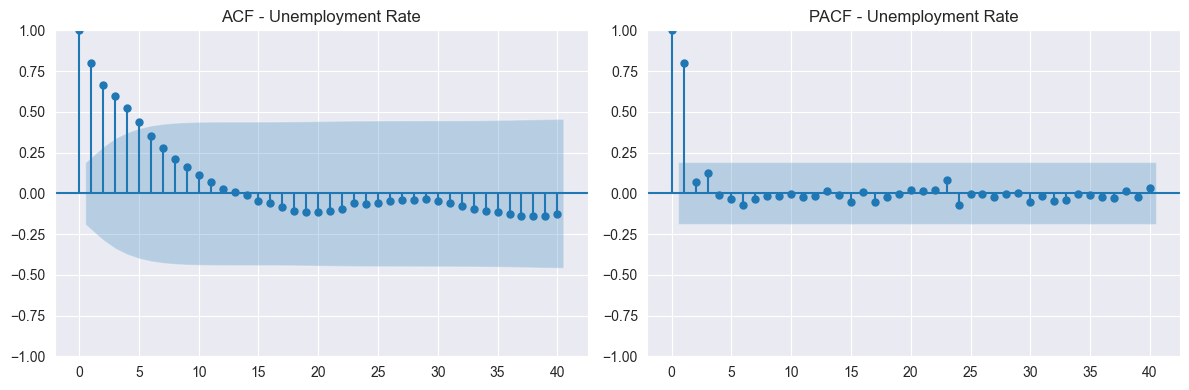

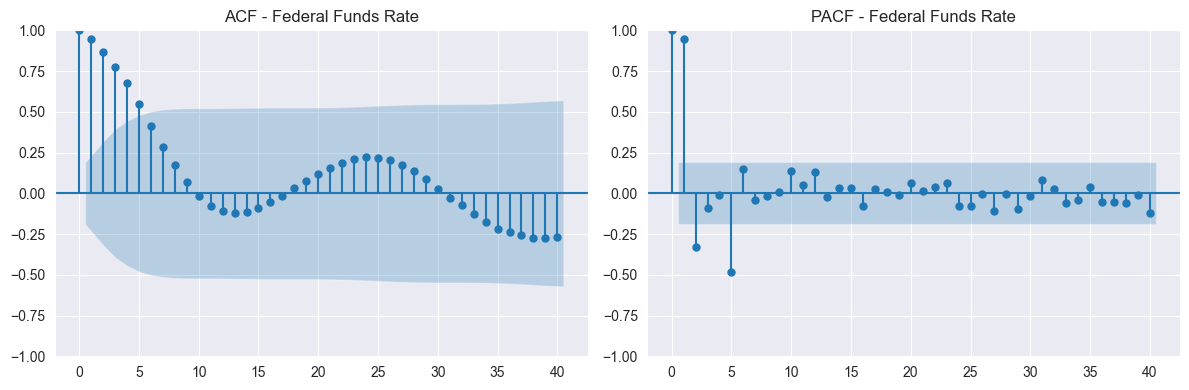

In [10]:
for column in Differenced_data.columns:

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    plot_acf(Differenced_data[column].dropna(), ax=axes[0], lags=40)
    axes[0].set_title(f"ACF - {column}")

    plot_pacf(Differenced_data[column].dropna(), ax=axes[1], lags=40, method="ywm")
    axes[1].set_title(f"PACF - {column}")

    plt.tight_layout()
    plt.show()

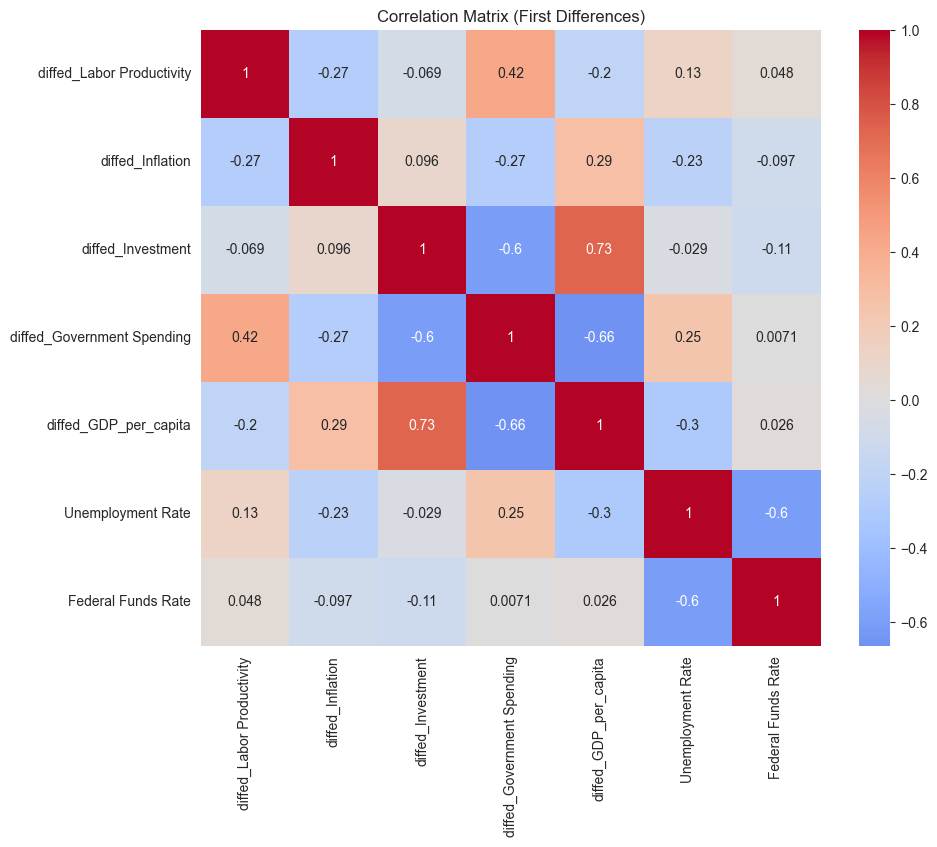

In [11]:
corr_diff = Differenced_data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (First Differences)")
plt.show()
